# Pitch Contour

---
This notebook introduces the pitch contour from fundamental frequency detection to pitch estimation. It focuses on the monophonic pitch estimation with hands-on Python examples and visualizations.

- **Section 0 - Pre-requisites**

  Setting up the environment with the required Python libraries.

- **Section 1 - Fundamental Frequency Detection**

  Introduce basic concepts in fundamental frequency detection and some frequeny use detection algorithms(ACF, AMDF,HPS). Use sine wave and oboe sound as example analysis.

- **Section 2 - Pitch Estimation**

  Use the PyACA computePitch function to estimate a monophonic vocal track. Analyze the sample with different detection algorithms(ACF, AMDF,HPS)

- **Section 3 - Evaluation Metrics**
  
  Introduce RMS to evaluate results from the pitch estimation. Compare different detection algorithms(ACF, AMDF,HPS)



# 0. Pre-requisites: setting up the environment

In [ ]:
# install the pyACA library
!pip install pyACA
!pip install pretty_midi
# When not using jupyter environment, please remember install below dependencies:
# !pip install numpy
# !pip install scipy


In [1]:
# Ignore the warning
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pyACA
from IPython.display import Audio, display
from utils.visualize import *

#1. Fundamental Frequency (F0) Detection Introduction
####References
Text book: [Sect. 7.3.3](https://ieeexplore.ieee.org/document/9966310)
Slides: [ACA-Mono-Tonal-Monof0.pdf](https://github.com/alexanderlerch/ACA-Slides/blob/2nd_edition/07-03-03-ACA-Tonal-Monof0.pdf)

###  1.1 Problem Definition

For a monophonic signal \(x(t)\), the goal of fundamental frequency detection is to estimate its **period** $\hat{T}_0$ and corresponding frequency

$$
\hat{f}_0 = \frac{1}{\hat{T}_0}.
$$

The signal can be modeled as **quasi-periodic**, meaning:

$$
x(t) \approx x(t + \hat{T}_0)
$$

and it can be approximated as a sum of harmonically related sinusoids:

$$
x(t) \approx \sum_{k=-\infty}^{\infty} a_k e^{j k \omega_0 t}, \quad \omega_0 = 2\pi \hat{f}_0.
$$

---

### 1.2 How to Detect Fundamental Frequency

There are many algorithms for estimating the **fundamental frequency (f₀)** in monophonic signals, each detecting periodicity in either the **time** or **frequency** domain.

In the **time domain**, we often use


- **Autocorrelation Function(ACF)**: measures waveform similarity over time lags to locate repeating patterns.  

  $$
  r_{xx}(\eta,n) = \sum_{i=i_s(n)}^{i_e(n)-\eta} x(i)\,x(i+\eta)
  $$
  The lag that maximizes $ r_{xx} $ gives the estimated period:  
  $$
  \hat{T}_0(n) = \arg\max_\eta r_{xx}(\eta,n).
  $$

- **Average Magnitude Difference Function (Amdf)**: performs a similar comparison using absolute differences instead of products, and **TimeAuditory** models the human auditory system by applying a filterbank, half-wave rectification, and periodicity analysis in each band before combining the results.

  $$
  \mathrm{AMDF}_{xx}(\eta,n) =
  \frac{1}{i_e(n)-i_s(n)+1}
  \sum_{i=i_s(n)}^{i_e(n)-\eta} |x(i) - x(i+\eta)|.
  $$
  The period is found at the lag of the **minimum** AMDF value:  
  $$
  \hat{T}_0(n) = \arg\min_\eta \mathrm{AMDF}_{xx}(\eta,n).
  $$

In the **frequency domain**, we often use

- **Harmonic Product Spectrum (SpectralHps)**: compresses the spectrum at integer multiples and multiplies them to emphasize the fundamental peak.  
$$
  X_{\mathrm{HPS}}(k,n) =
  \prod_{j=1}^{\mathcal{O}} |X(j \cdot k,n)|^2,
  \qquad
  \hat{f}_0(n) = \arg\max_k X_{\mathrm{HPS}}(k,n).
  $$

We are using different algorithms for detecting pitch for every frame using [`computePitch()`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/computePitch.py) from the pyACA repo.

Supported pitch extraction methods are:
-    [`SpectralAcf`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchSpectralAcf.py),
-    [`SpectralHps`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchSpectralHps.py),
-    [`TimeAcf`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchTimeAcf.py),
-    [`TimeAmdf`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchTimeAmdf.py),
-    [`TimeAuditory`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchTimeAuditory.py),
-    [`TimeZeroCrossings`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchTimeZeroCrossings.py).

Please click on the function name as reference link for more implementation details!



### 1.3 Visualize different fundamental frequency detection algorithms

In this section, we are going to visualize and compare different fundamental frequency detection algorithm on a simple example. We generate a ground truth sine wave signal at 440hz. We will see how the different algorithm behave in detecting this simple signal. Since the pure sine wave does not work for Hps, we will use Acf and Admf as comparison. Then, we use an example of sawsooth wave to show the SpectralHps algorithm.

Estimate freq rms:  1.0
Estimate midi rms:  0.039301584394337404


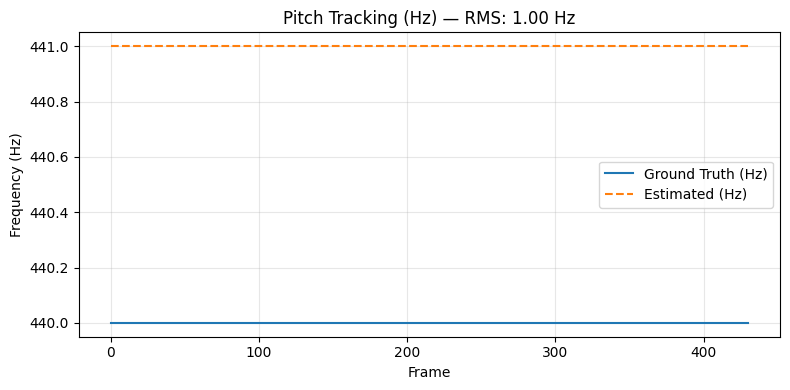

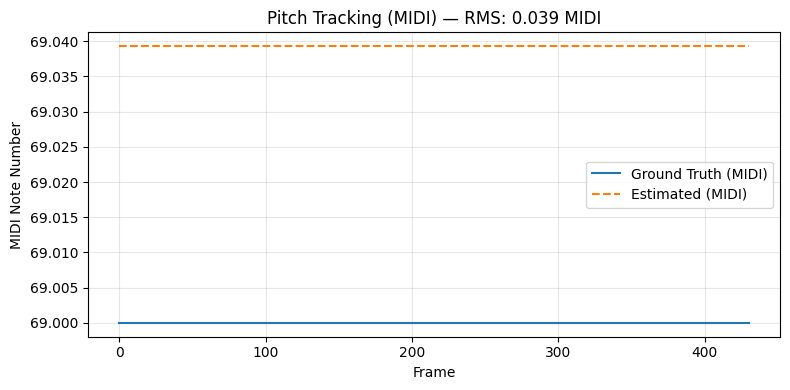

In [2]:
import time
from utils.eval import eval_pitchtrack
from utils.base import sawtoothWavGen, sineWavGen
from pyACA import ToolFreq2Midi
from utils.visualize import visualizePitchTracking
# generate a sine wave at frequency 440hz
wav, sr, gt_qfreq = sineWavGen(440, 5, sr=44100, iBlockLength=4096)
gt_midi = ToolFreq2Midi(gt_qfreq)
iBlockLength=4096
iHopLength=512

est_freq_acf, est_time_acf = pyACA.computePitch('TimeAcf', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_midi_acf = ToolFreq2Midi(est_freq_acf)
acf_rms_freq_error = eval_pitchtrack(estimate=est_freq_acf, groundtruth=gt_qfreq, mode='freq')
acf_rms_midi_error = eval_pitchtrack(estimate=est_midi_acf, groundtruth=gt_midi, mode='pitch')

print("Estimate freq rms: ", acf_rms_freq_error)
print("Estimate midi rms: ", acf_rms_midi_error)
visualize_tracking_freq(est_freq_acf,gt_qfreq,acf_rms_freq_error)
visualize_tracking_midi(est_midi_acf,gt_midi,acf_rms_midi_error)

Estimate freq rms:  326.9477432500344
Estimate midi rms:  23.780108148282


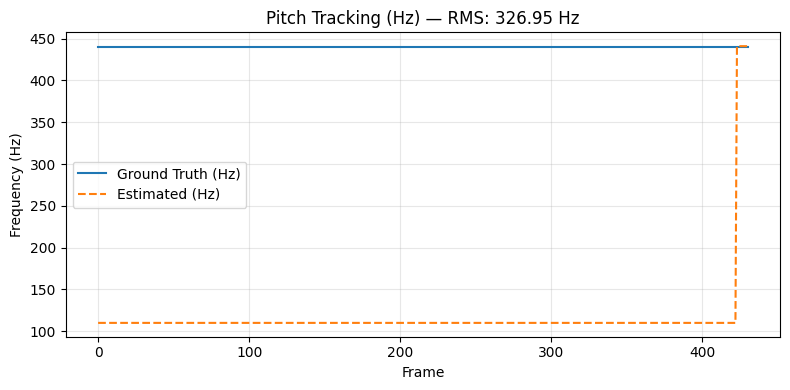

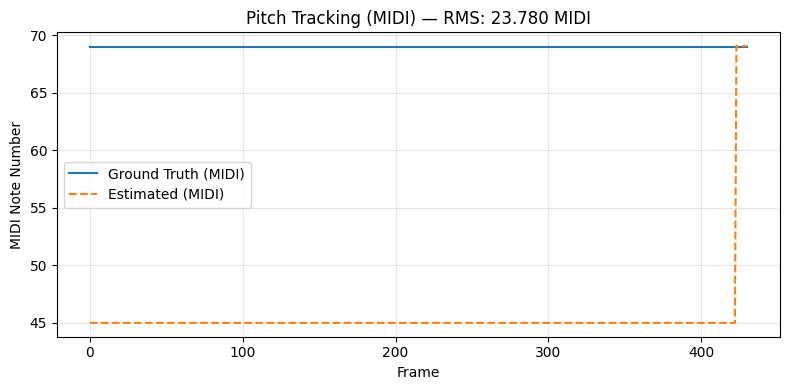

In [3]:
# use amdf
est_freq_amdf, est_time_amdf = pyACA.computePitch('TimeAmdf', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_midi_amdf = ToolFreq2Midi(est_freq_amdf)
amdf_rms_freq_error = eval_pitchtrack(estimate=est_freq_amdf, groundtruth=gt_qfreq, mode='freq')
amdf_rms_midi_error = eval_pitchtrack(estimate=est_midi_amdf, groundtruth=gt_midi, mode='pitch')

print("Estimate freq rms: ", amdf_rms_freq_error)
print("Estimate midi rms: ", amdf_rms_midi_error)

visualize_tracking_freq(est_freq_amdf,gt_qfreq,amdf_rms_freq_error)
visualize_tracking_midi(est_midi_amdf,gt_midi,amdf_rms_midi_error)

Estimate freq rms:  10.628796923388995
Estimate midi rms:  0.5008404915422902


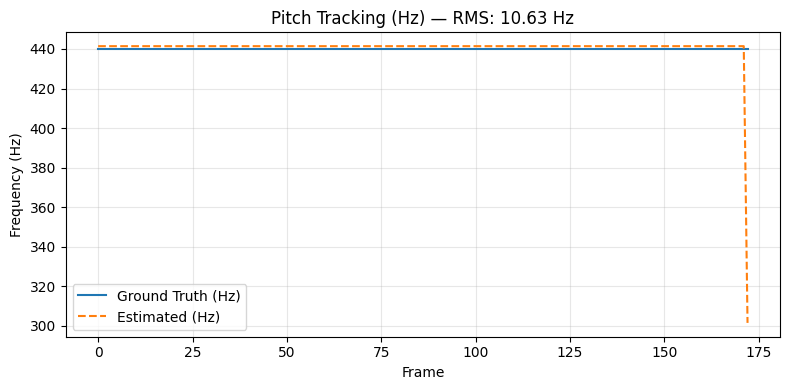

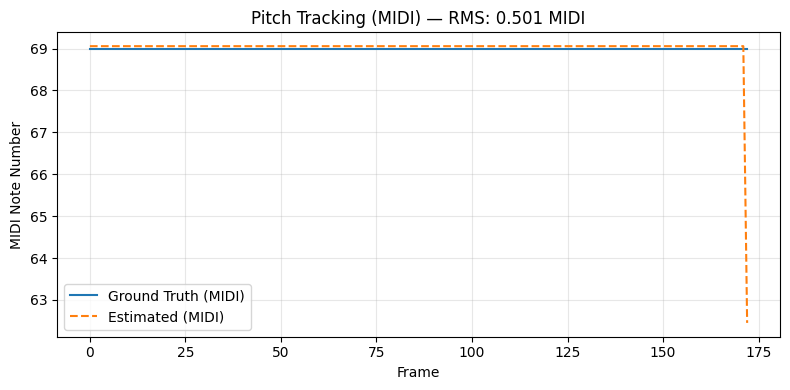

In [4]:
wav, sr, gt_qfreq = sawtoothWavGen(440, 2, sr=44100, iBlockLength=4096)
gt_midi = ToolFreq2Midi(gt_qfreq)
iBlockLength=4096
iHopLength=512

est_freq_hps, est_time_hps = pyACA.computePitch('SpectralHps', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_midi_hps = ToolFreq2Midi(est_freq_hps)
hps_rms_freq_error = eval_pitchtrack(estimate=est_freq_hps, groundtruth=gt_qfreq, mode='freq')
hps_rms_midi_error = eval_pitchtrack(estimate=est_midi_hps, groundtruth=gt_midi, mode='pitch')

print("Estimate freq rms: ", hps_rms_freq_error)
print("Estimate midi rms: ", hps_rms_midi_error)


visualize_tracking_freq(est_freq_hps,gt_qfreq,hps_rms_freq_error)
visualize_tracking_midi(est_midi_hps,gt_midi,hps_rms_midi_error)

From above statistics and figures, we can observe that

- ACF (Autocorrelation Function) performs extremely well on clean periodic signals like a pure sine wave. It only has RMS error (Hz): 1.00
and RMS error (MIDI note): 0.039. Because the sinewave has a single fundamental component, the autocorrelation function produces a clear and dominant peak at the true period, giving stable and accurate detection.

- Amdf, however, performed poorly on this pure sinewave. It presents the subharmonic confusion and only has quater frequency in estimation. It results in high RMS error (Hz): ≈ 326.95 and RMS error (MIDI): ≈ 23.78.  

- HPS performed pretty good on sawtooth wave because Sawtooth waves contain rich harmonics at integer multiples of $F_0$. It results in good RMS error (Hz): ≈ 10.63, RMS error (MIDI note): ≈ 0.501 MIDI.

###1.4 Visualize with chromatic scale of pure wave signal
In this section, we further expand the complexity of fundamental frequency detection. We tried to visualize how ACF and AMDF behave on estimating a chromatic scale of sine wave in sequence and how HPS bahaves on estimating chromatic scale of sawtooth wave

ACF midi rms:  0.10691979579960446


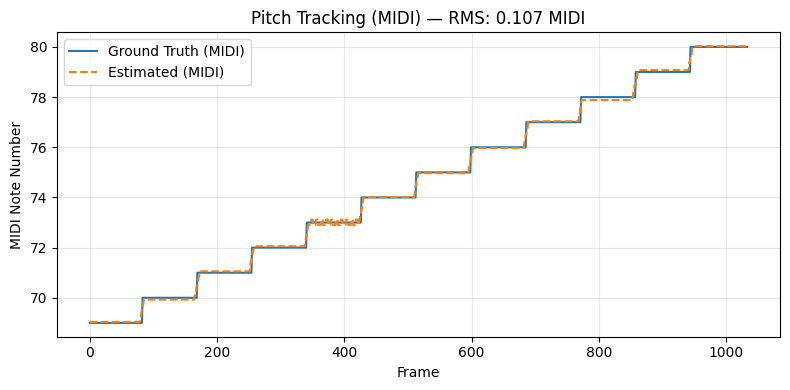

AMDF midi rms:  32.386910345648246


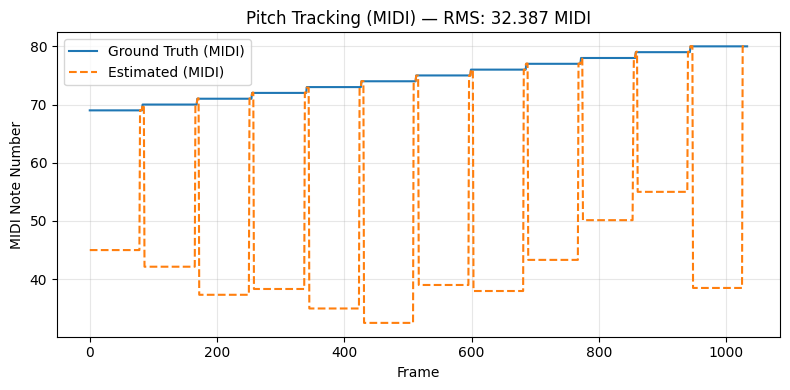

In [3]:
from utils.base import gen_chromatic_scale
wav, sr, gt_qfreq, gt_midi = gen_chromatic_scale(
    start_midi=69, n_semitones=12, seconds_per_note=1.0,
    sr=sr, iBlockLength=4096, iHopLength=512
)

# ACF estimation
est_freq_acf, est_time_acf = pyACA.computePitch('TimeAcf', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_midi_acf = ToolFreq2Midi(est_freq_acf)
acf_rms_midi_error = eval_pitchtrack(estimate=est_midi_acf, groundtruth=gt_midi, mode='pitch')
print("ACF midi rms: ", acf_rms_midi_error)
visualize_tracking_midi(est_midi_acf,gt_midi,acf_rms_midi_error)

# AMDF estimation
est_freq_amdf, est_time_amdf = pyACA.computePitch('TimeAmdf', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_midi_amdf = ToolFreq2Midi(est_freq_amdf)
amdf_rms_midi_error = eval_pitchtrack(estimate=est_midi_amdf, groundtruth=gt_midi, mode='pitch')
print("AMDF midi rms: ", amdf_rms_midi_error)
visualize_tracking_midi(est_midi_amdf,gt_midi,amdf_rms_midi_error)


HPS midi rms:  5.857693491630125


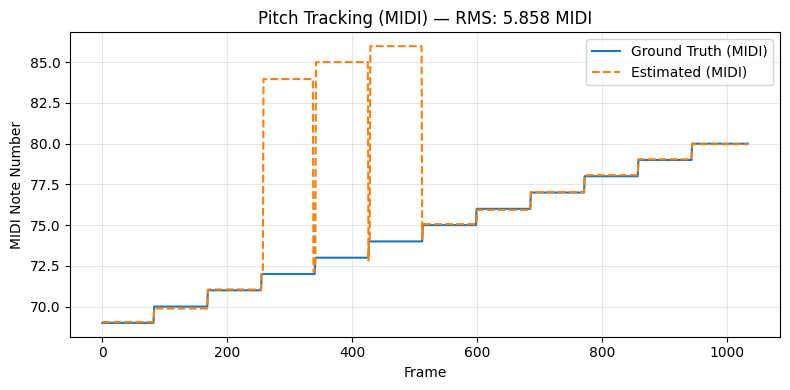

In [5]:
from utils.base import gen_chromatic_scale_saw
wav, sr, gt_qfreq, gt_midi = gen_chromatic_scale_saw(
    start_midi=69, n_semitones=12, seconds_per_note=1.0,
    sr=sr, iBlockLength=4096, iHopLength=512
)

#HPS estimation
est_freq_hps, est_time_hps = pyACA.computePitch('SpectralHps', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_midi_hps = ToolFreq2Midi(est_freq_hps)
hps_rms_midi_error = eval_pitchtrack(estimate=est_midi_hps, groundtruth=gt_midi, mode='pitch')
print("HPS midi rms: ", hps_rms_midi_error)
visualize_tracking_midi(est_midi_hps,gt_midi,hps_rms_midi_error)


### 1.5 Visualize frequency detection algorithms with audio example
Let's visualize the detect with an actual instrument audio example. We use the example of ``keyboard_electronic_002-081-100.wav`` from the [``The NSynth Dataset``](https://magenta.withgoogle.com/datasets/nsynth#description)'s test set. The dataset contain the ground truth label of pitch in the json file, therefore, we use the labeled midi pitch as ground truth reference. Our chosen sample has the midi note of 81.

<Axes: title={'center': 'STFT Magnitude (dB)'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>

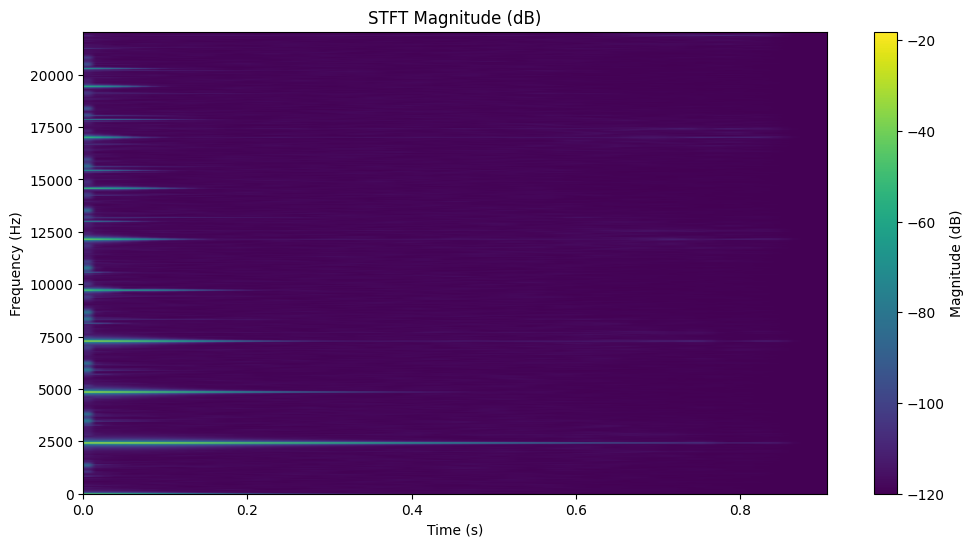

In [5]:
from pyACA import ToolReadAudio
from pyACA import computeSpectrogram
from pyACA.ToolPreprocAudio import ToolPreprocAudio
#load the audio
# Settings
iBlockLength = 4096
iHopLength = 512
f_s, wav = ToolReadAudio('Audio_Asset/03-PitchContour/02-keyboard_electronic_002-081-100.wav')
max_samples = int(2.5 * f_s)
wav = wav[:max_samples]

X = ToolPreprocAudio(wav)
# display the audio
display(Audio(X, rate=int(f_s)))

X, f, t = computeSpectrogram(wav, f_s, iBlockLength=4096, iHopLength=512)

visualizeSpec(X, sr, fig_width=12, fig_height=6)

Estimate midi rms:  15.785468738177192


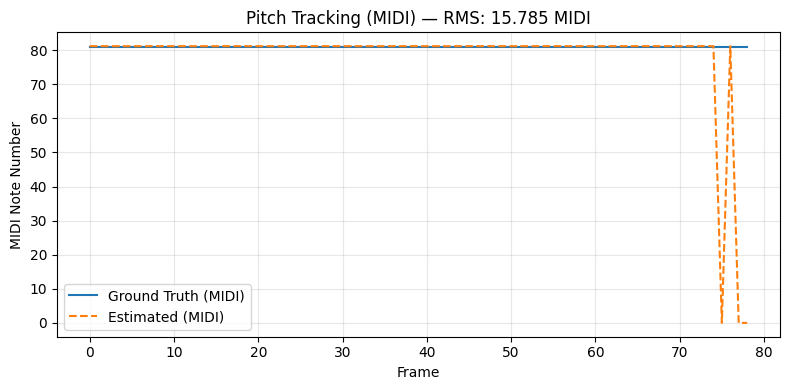

In [6]:
# use Acf as estimation
est_freq, est_time = pyACA.computePitch('TimeAcf', wav, f_s, iBlockLength=1024, iHopLength=512)
est_midi = ToolFreq2Midi(est_freq)
est_midi = np.asarray(est_midi, dtype=float).squeeze()

gt_midi = np.full_like(est_midi, 81.0)
rms_midi_error = eval_pitchtrack(estimate=est_midi, groundtruth=gt_midi, mode='pitch')

print("Estimate midi rms: ", rms_midi_error)

visualize_tracking_midi(est_midi,gt_midi,rms_midi_error)

Estimate midi rms:  32.42461153320425


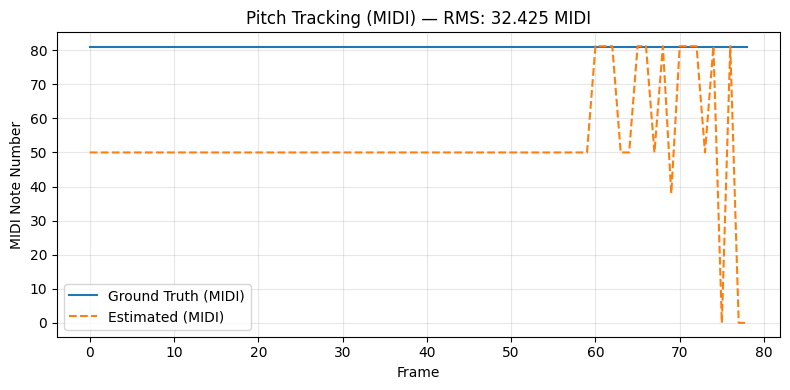

In [7]:
# use amdf estimation
est_freq, est_time = pyACA.computePitch('TimeAmdf', wav, f_s, iBlockLength=4096, iHopLength=512)
est_midi = ToolFreq2Midi(est_freq)
est_midi = np.asarray(est_midi, dtype=float).squeeze()
gt_midi = np.full_like(est_midi, 81.0)

rms_midi_error = eval_pitchtrack(estimate=est_midi, groundtruth=gt_midi, mode='pitch')
print("Estimate midi rms: ", rms_midi_error)

visualize_tracking_midi(est_midi,gt_midi,rms_midi_error)

Estimate midi rms:  3.5154687269009948


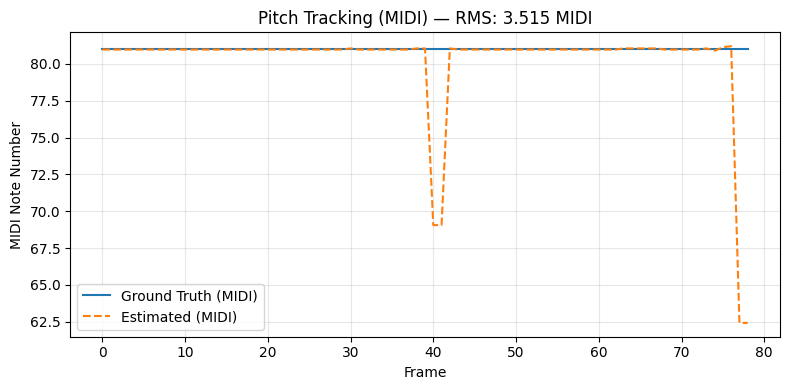

In [8]:
# use spectral hps estimation
est_freq, est_time = pyACA.computePitch('SpectralHps', wav, f_s, iBlockLength=4096, iHopLength=512)
est_midi = ToolFreq2Midi(est_freq)
est_midi = np.asarray(est_midi, dtype=float).squeeze()
gt_midi = np.full_like(est_midi, 81.0)

rms_midi_error = eval_pitchtrack(estimate=est_midi, groundtruth=gt_midi, mode='pitch')
print("Estimate midi rms: ", rms_midi_error)

visualize_tracking_midi(est_midi,gt_midi,rms_midi_error)

For the electronic keyboard sound at midi note of 81,

- ACF Generally tracks at 81 MIDI as the figure shows, but statistically has poor performance. It tracks perfectly for the first 70 frame, but fails dramastically when the signal starts to decay.  The the sudden vertical jumps between 0 and 80 results the large RMS error of 15.78 MIDI.

- Amdf seems to have very poor performance. The RMS of 32.42 MIDI is high, but given the constant -31 MIDI error. This is the extreme version of the subharmonic error. On this high note, the unconstrained AMDF is unusable; it fails to find the true period altogether.

- HPS is the best among three for this sample. The RMS of 3.515 MIDI is lowest by far. Because the electronic keyboard sound has very strong, well-defined, and precisely spaced harmonics. HPS correctly reinforces the $F_0$ peak and suppresses the subharmonics and noise, leading to accurate tracking. However there are the large spikes down to $\approx 62  MIDI$ is possibly where the HPS product was disrupted by inharmonic components or noise in the spectrogram.

## 2. Pitch estimation function
In this section we are using a audio sample from [``Choral Singing Dataset``](https://zenodo.org/records/2649950), and estimate the pitch of this sample. The sample is an monophonic alto vocal audio which given a midi reference.  

In the below, you can replace any pitch contour algorithm you would like to try!

<Figure size 1200x600 with 0 Axes>

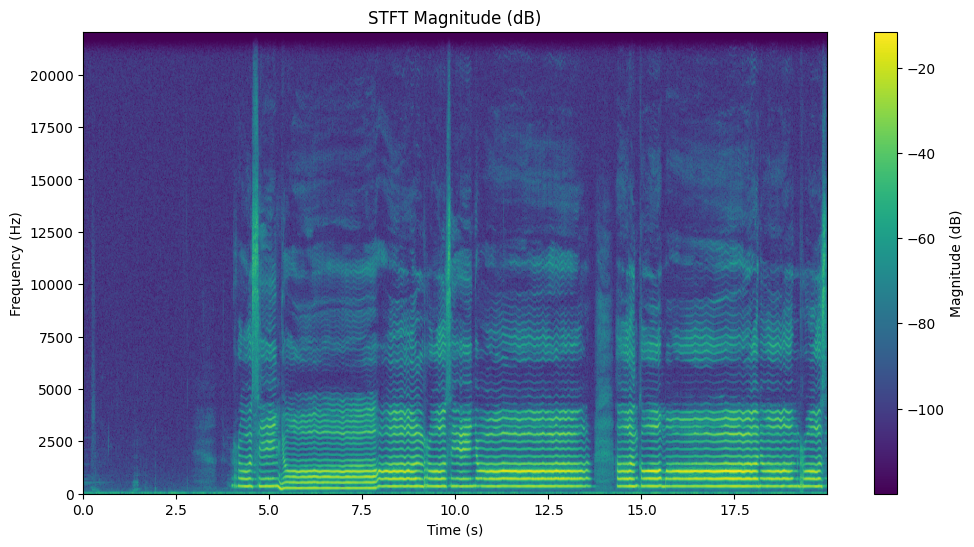

<Figure size 1200x600 with 0 Axes>

In [26]:
# Read audio
import pretty_midi
sr, wav = ToolReadAudio("Audio_Asset/03-PitchContour/01-CSD_ER_alto_1.wav")
# only load first 20 seconds of audio
max_samples = int(20 * sr)
wav = wav[:max_samples]
X = ToolPreprocAudio(wav)
display(Audio(X, rate=int(sr)))

X, f, t = computeSpectrogram(wav, sr, iBlockLength=1024, iHopLength=512)
visualizeSpec(X, sr, fig_width=12, fig_height=6)

# only keep first 20 seconds of midi
midi_path = "Audio_Asset/03-PitchContour/01-CSD_ER_alto_midi.mid"
midi_data = pretty_midi.PrettyMIDI(midi_path)
trim_end = 20.0
for inst in midi_data.instruments:
    inst.notes = [n for n in inst.notes if n.start < trim_end]
    for n in inst.notes:
        if n.end > trim_end:
            n.end = trim_end

plt.figure(figsize=(12, 6))


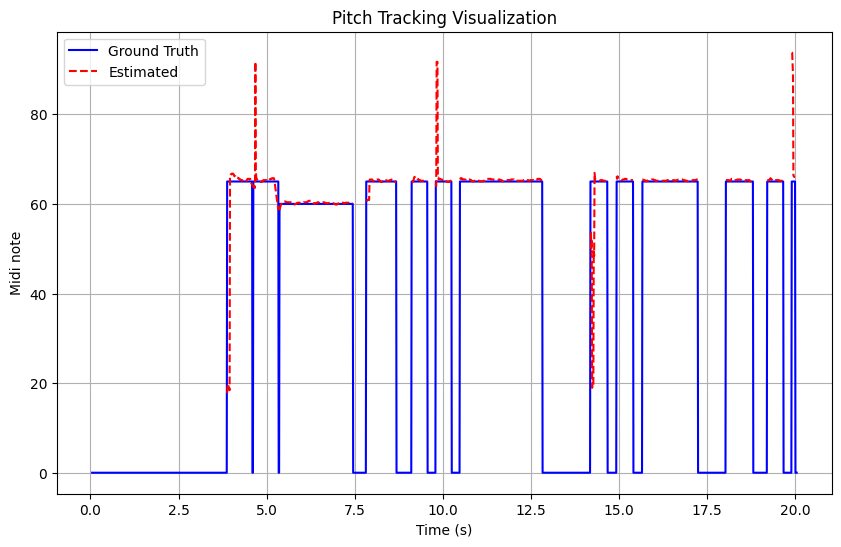

In [27]:
# estimate with computPitch
pitchAlgo = 'TimeAcf' # replace with options: SpectralAcf, SpectralHps, TimeAcf, TimeAmdf, TimeAuditory, TimeZeroCrossings
est_freq_acf, est_time_acf = pyACA.computePitch(pitchAlgo, wav, sr, iBlockLength=4096, iHopLength=512)
est_midi_acf = ToolFreq2Midi(est_freq_acf)

# create mask of where note is active
note_mask = midi_note_mask(midi_data, est_time_acf)
est_midi_masked_acf = np.where(note_mask, est_midi_acf, np.nan)

# convert the pretty midi object to array as ground truth result
midi_pitches, midi_starts, midi_ends = midi_to_array(midi_data)
gt_pitch = np.zeros_like(est_time_acf)
for pitch, start, end in zip(midi_pitches, midi_starts, midi_ends):
    mask = (est_time_acf >= start) & (est_time_acf <= end)
    gt_pitch[mask] = pitch

# visualize
visualizePitchTracking(est_time_acf, gt_pitch, est_time=est_time_acf, est_midi=est_midi_masked_acf)

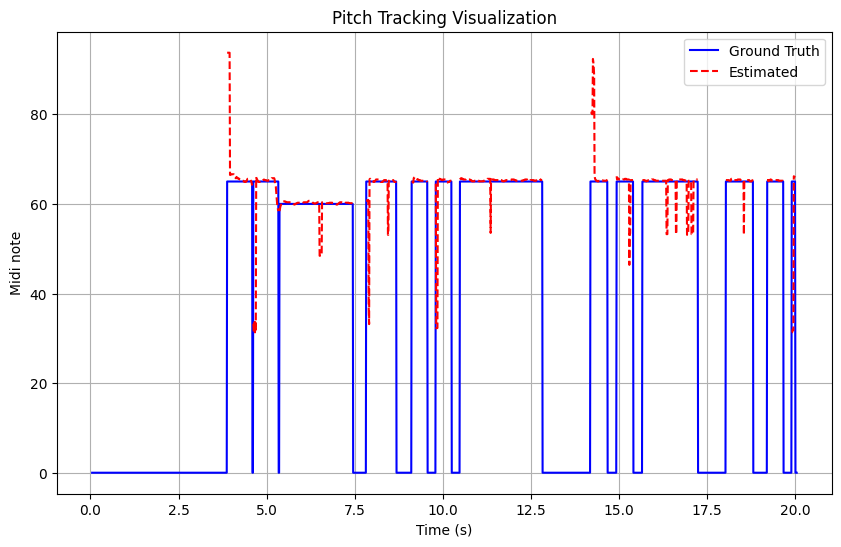

In [28]:
# estimate with TimeAmdf
pitchAlgo = 'TimeAmdf' # replace with options: SpectralAcf, SpectralHps, TimeAcf, TimeAmdf, TimeAuditory, TimeZeroCrossings
est_freq_amdf, est_time_amdf = pyACA.computePitch(pitchAlgo, wav, sr, iBlockLength=4096, iHopLength=512)
est_midi_amdf = ToolFreq2Midi(est_freq_amdf)
# create mask where only note is active
note_mask = midi_note_mask(midi_data, est_time_amdf)
est_midi_masked_amdf = np.where(note_mask, est_midi_amdf, np.nan)
# visualize
visualizePitchTracking(est_time_amdf, gt_pitch, est_time=est_time_amdf, est_midi=est_midi_masked_amdf)

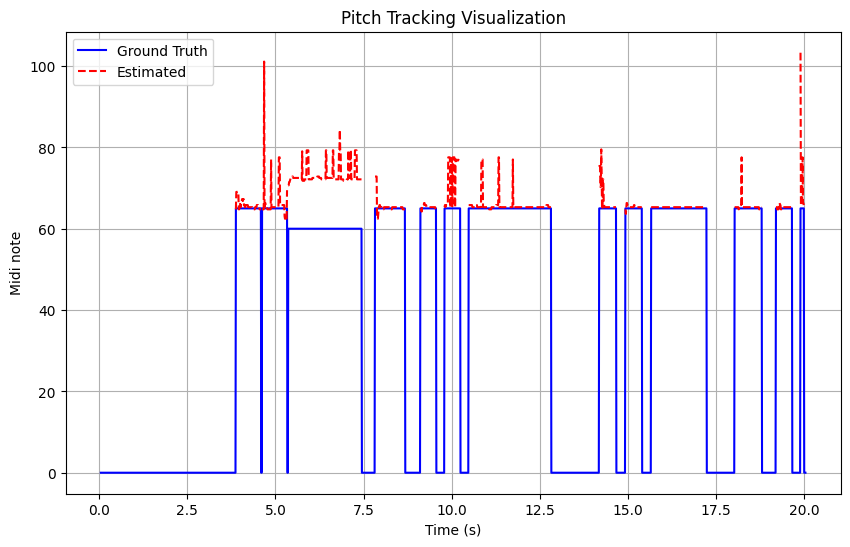

In [29]:
# estimate with SpectralHps
pitchAlgo = 'SpectralHps' # replace with options: SpectralAcf, SpectralHps, TimeAcf, TimeAmdf, TimeAuditory, TimeZeroCrossings
est_freq_hps, est_time_hps = pyACA.computePitch(pitchAlgo, wav, sr, iBlockLength=4096, iHopLength=512)
est_midi_hps = ToolFreq2Midi(est_freq_hps)

# mask where only note is active
est_midi_masked_hps = np.where(note_mask, est_midi_hps, np.nan)
# visualize
visualizePitchTracking(est_time_hps, gt_pitch, est_time=est_time_hps, est_midi=est_midi_masked_hps)

Visually, the plots for ACF and AMDF are very similar, both showing tight tracking during active speech and similar failure spikes in silence. They are both excellent at finding the period of the quasi-periodic vocal waveform.

HPS is noticeably noisier during the sustained notes. Looking at the plot for the HPS result, there are times (e.g., $t \approx 5.5-8.0 \text{ s}$ and $t \approx 10.0-13.0 \text{ s}$) where the estimated red line is consistently tracking too high (e.g., between MIDI 70 and 80) even when the ground truth is MIDI 60-65. This confirms that HPS is mistakenly locking onto a stronger harmonic during sustained vowel sounds, which dramatically increases its RMS error.

## 3. Evaluation
To quantitatively assess the performance of our pitch estimation algorithm, we evaluated the difference between the estimated and ground-truth fundamental frequencies in the pitch (MIDI) domain.
Because pitch perception is logarithmic, we first converted all frequency values (in Hz) to MIDI note numbers using [``ToolFreq2Midi``](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/ToolFreq2Midi.py).
We then computed the root mean square error (RMSE) in semitones,

$$\left( \frac{1}{N} \sum_{i=1}^{N} e_i^2 \right)^{1/2}$$

where $e_i$ is the pitch estimation error (in cents or semitones) for frame $i$, and $ N $ is the total number of valid frames.

RMS error is a good metric because it provides a scale-independent, perceptually meaningful, and statistically robust measure of pitch estimation accuracy.
It punishes large deviations (octave flips, wrong partials) more heavily while still capturing small-scale fluctuations, making it an ideal summary statistic for continuous $F_0$ tracking evaluation.

Therefore, the evaluation ensures that the results are not biased by absolute frequency magnitude and reflect true perceptual deviations from the reference pitch.


In [30]:
from utils.eval import eval_pitchtrack_midi

rms_acf = eval_pitchtrack_midi(est_midi_masked_acf, gt_pitch)
rms_amdf = eval_pitchtrack_midi(est_midi_masked_amdf, gt_pitch)
rms_hps = eval_pitchtrack_midi(est_midi_masked_hps, gt_pitch)

print('RMS error of ACF algo: ', rms_acf)
print('RMS error of AMDF algo: ', rms_amdf)
print('RMS error of HPS algo: ', rms_hps)

RMS error of ACF algo:  5.554128605917795
RMS error of AMDF algo:  5.790610941150582
RMS error of HPS algo:  6.519255319922759


From the RMS value, we can know that the ACF has best performance, then folloed by AMDF and HPS has the worst performance. Though visually ACF and AMDF fit the ground truth value very well, there are still high RMS error around 5.5-5.7 MIDI notes. This is because there are outliers of silence and noise. The major errors stem from the tracker locking onto noise or spurious high frequencies during silent gaps and transitions. Also, Human voice pitch is naturally unstable, containing vibrato and slight intonation drift, which increases the ground truth difference and therefore the RMS, even if the algorithm is musically correct.

For HPS, as we observed from figure, HPS relies on the precise alignment of harmonic peaks. If the vocal pitch is slightly wavering or inharmonic, the multiplication step in HPS fails to produce a single, distinct peak, leading HPS to jump to a stronger, but incorrect, harmonic.

Therefore, we can summarize when to use these 3 algorithms respectively:

- ACF is highly effective at finding the period of a repetitive waveform, natural, harmonic sounds as well as noisy or reverberant environments

- AMDF could be use when computational simplicity is prioritized since it computes absolute differences rather than correlations

- HPS should applied in the situation of complex, polyharmonic sounds with strong overtones and cases which is stable in frequency-domain.

